# Decision Tree Classifier

## Project Overview

This project builds a Decision Tree Classification model using Python and Scikit-learn.

The objective is to prepare the dataset, train a Decision Tree classifier, evaluate its performance, and visualize the resulting decision tree.

## Dataset

This project uses the **Bank Marketing Dataset**.

The dataset contains information about customers contacted during marketing campaigns and whether they subscribed to a term deposit.

**Dataset Source:** UCI Machine Learning Repository

**Target Variable:** `y`

The target indicates whether the customer subscribed to the product:
- `yes` — customer subscribed
- `no` — customer did not subscribe

In [1]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"

# Read the dataset from UCI
import zipfile
import io
import requests

response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open("bank-full.csv") as f:
        df = pd.read_csv(f, sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [3]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.select_dtypes(include='object').nunique()

C:\Users\HP\AppData\Local\Temp\ipykernel_13776\3404847108.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').nunique()


job          12
marital       3
education     4
default       2
housing       2
loan          2
contact       3
month        12
poutcome      4
y             2
dtype: int64

In [6]:
# Separate features and target
X = df.drop('y', axis=1)
y = df['y']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (45211, 16)
Target shape: (45211,)


In [7]:
# Convert target values to numerical labels
y = y.map({'no': 0, 'yes': 1})

y.value_counts()

y
0    39922
1     5289
Name: count, dtype: int64

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical columns
categorical_columns = X.select_dtypes(include='object').columns
numerical_columns = X.select_dtypes(exclude='object').columns

print("Categorical columns:")
print(list(categorical_columns))

print("\nNumerical columns:")
print(list(numerical_columns))

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


C:\Users\HP\AppData\Local\Temp\ipykernel_13776\1183106385.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include='object').columns


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_columns),
        ('numerical', 'passthrough', numerical_columns)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [24]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (36168, 16)
Testing set: (9043, 16)


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        max_depth=5,
        class_weight='balanced'
    ))
])

# Train the model using the training data
model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [26]:
# Make predictions on the test data
y_pred = model.predict(X_test)

print("Predictions made successfully!")
print("First 10 predictions:", y_pred[:10])

Predictions made successfully!
First 10 predictions: [0 0 0 0 0 1 0 1 0 0]


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))

Accuracy : 0.7556
Precision: 0.3067
Recall   : 0.8639


In [28]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[5919 2066]
 [ 144  914]]


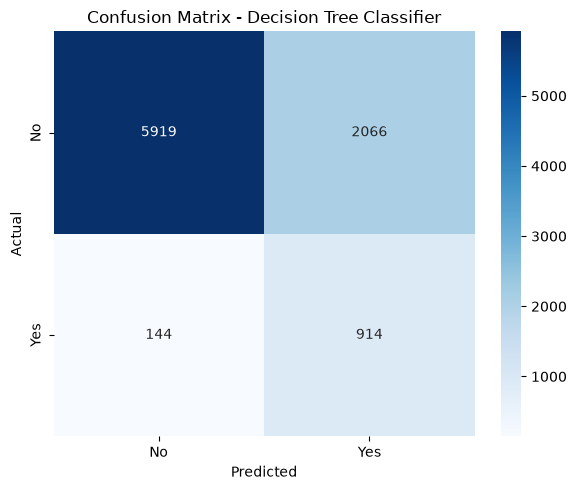

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree Classifier')

plt.tight_layout()

# Save the image
plt.savefig('confusion_matrix.png', dpi=300)

plt.show()

In [16]:
# Get feature names after preprocessing
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Get feature importance from the Decision Tree
importances = model.named_steps['classifier'].feature_importances_

# Create a table of features and their importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display the top 5 features
top_5_features = feature_importance.head(5)

top_5_features

,Feature,Importance
47,numerical__duration,0.580995
42,categorical__poutcome_success,0.183117
27,categorical__contact_unknown,0.116943
22,categorical__housing_yes,0.076645
38,categorical__month_oct,0.022956


In [17]:
# Convert transformed feature names into original feature names

def get_original_feature(feature_name):
    if feature_name.startswith("numerical__"):
        return feature_name.replace("numerical__", "", 1)

    for col in categorical_columns:
        if feature_name.startswith(f"categorical__{col}_"):
            return col

    return feature_name


# Add original feature names
feature_importance["Original Feature"] = feature_importance["Feature"].apply(
    get_original_feature
)

# Combine importance values of one-hot encoded categories
aggregated_importance = (
    feature_importance
    .groupby("Original Feature", as_index=False)["Importance"]
    .sum()
    .sort_values(by="Importance", ascending=False)
)

# Display top 5 original features
top_5_original = aggregated_importance.head(5)

top_5_original

,Original Feature,Importance
6,duration,0.580995
14,poutcome,0.183117
3,contact,0.118641
8,housing,0.076645
12,month,0.036916


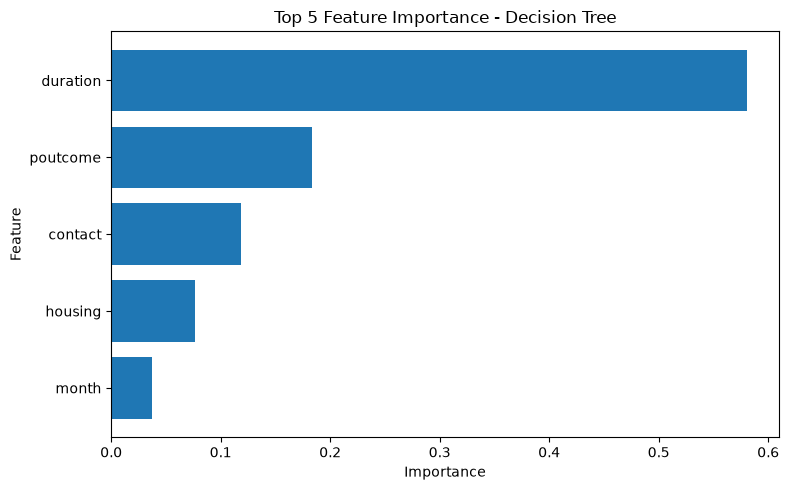

In [18]:
import matplotlib.pyplot as plt

# Plot top 5 feature importance
plt.figure(figsize=(8, 5))

plt.barh(
    top_5_original["Original Feature"],
    top_5_original["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 5 Feature Importance - Decision Tree")

# Show the most important feature at the top
plt.gca().invert_yaxis()

plt.tight_layout()

# Save the chart
plt.savefig("top_5_feature_importance.png", dpi=300)

plt.show()

## Model Evaluation

The Decision Tree classifier was evaluated using the test dataset.

The dataset was divided into 80% training data and 20% testing data. The model achieved an accuracy of **75.56%**, precision of **30.67%**, and recall of **86.39%**.

The confusion matrix shows the number of correct and incorrect predictions for both classes.

The top five features based on aggregated feature importance were:

1. Duration
2. Poutcome
3. Contact
4. Housing
5. Month

Among these features, **duration** had the highest importance in the Decision Tree model.

## Conclusion

The Decision Tree classifier was successfully trained to predict whether a customer would subscribe to a term deposit.

The preprocessing pipeline handled categorical variables using one-hot encoding and kept numerical variables unchanged. The model was evaluated using accuracy, precision, recall, and a confusion matrix.

The feature importance analysis showed that duration, previous campaign outcome, contact type, housing loan status, and month were the five most important features used by the model.